In [67]:
from datasets import load_dataset
import warnings
# Suppress all warnings globally
warnings.filterwarnings("ignore")
dataset = load_dataset("llangnickel/long-covid-classification-data")

In [68]:
dataset

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'text', 'label'],
        num_rows: 414
    })
    test: Dataset({
        features: ['Unnamed: 0', 'text', 'label'],
        num_rows: 138
    })
})

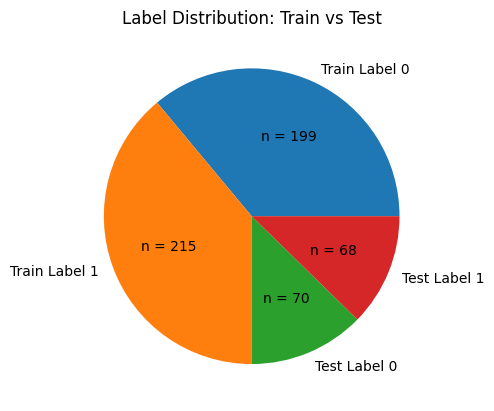

In [73]:
import matplotlib.pyplot as plt

# Extract labels
train_labels = dataset["train"]["label"]
test_labels = dataset["test"]["label"]

# Count each group
train_0 = sum(1 for x in train_labels if x == 0)
train_1 = sum(1 for x in train_labels if x == 1)
test_0 = sum(1 for x in test_labels if x == 0)
test_1 = sum(1 for x in test_labels if x == 1)

sizes = [train_0, train_1, test_0, test_1]

labels = [
    "Train Label 0",
    "Train Label 1",
    "Test Label 0",
    "Test Label 1"
]

# Custom function to show counts instead of %
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"n = {count}"
    return my_autopct

plt.figure()
plt.pie(sizes, labels=labels, autopct=make_autopct(sizes))
plt.title("Label Distribution: Train vs Test")
plt.show()

In [72]:
import math

def check_missing(split_name, labels):
    missing = sum(
        1 for x in labels
        if x is None or (isinstance(x, float) and math.isnan(x))
    )
    print(f"{split_name}: {missing} missing values out of {len(labels)}")

check_missing("Train", dataset["train"]["label"])
check_missing("Test", dataset["test"]["label"])

Train: 0 missing values out of 414
Test: 0 missing values out of 138
